In [1]:
# IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\misvs\Desktop\Python_Diwali_Sales_Analysis_project\Python_Diwali_Sales_Analysis\Diwali Sales Data.csv",
                 encoding = 'latin1')

In [3]:
df.head(3)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [5]:
## Here, Two columns are completly blank

df.drop(columns = ['Status','unnamed1'], inplace = True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


In [7]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [8]:
df[df.isnull().any(axis = 1)]

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN
14,1003858,Cano,P00293742,M,46-50,46,1,Madhya Pradesh,Central,Hospitality,Auto,3,NaN
16,1005447,Amy,P00275642,F,46-50,48,1,Andhra Pradesh,Southern,IT Sector,Auto,3,NaN
109,1005265,Sakshi,P00296242,F,46-50,48,1,Delhi,Central,Banking,Footwear & Shoes,1,NaN
111,1005261,Apoorva,P00057942,F,36-45,41,1,Delhi,Central,IT Sector,Footwear & Shoes,2,NaN
184,1005538,Kartik,P00269542,F,46-50,49,1,Karnataka,Southern,Banking,Footwear & Shoes,1,NaN
293,1000326,Jonathan,P00120542,M,51-55,53,0,Gujarat,Western,IT Sector,Footwear & Shoes,3,NaN
344,1002507,Lakshmi,P00045842,F,26-35,35,1,Gujarat,Western,Chemical,Furniture,1,NaN
345,1004498,Srishti,P00030842,F,51-55,55,0,Delhi,Central,Textile,Footwear & Shoes,1,NaN
452,1004601,Gaurav,P00014442,F,36-45,40,1,Madhya Pradesh,Central,Hospitality,Food,4,NaN


In [9]:
### In this scenario, We will remove the null's cuz accuracy matter's more than filling guess.

df.dropna(inplace = True)

In [10]:
df.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

# KPI'S

#### Total Sales

In [11]:
df['Total Sales'] = df['Orders']*df['Amount']

TS = round(df['Total Sales'].sum(),2)

print(f'Total Sales : {TS}')

Total Sales : 263658809.33


#### Total Orders

In [12]:
TO = len(df)

print(f'Total Orders : {TO}')

Total Orders : 11239


#### Sales Per Order

In [13]:
SPO = round(df['Total Sales'].mean(),2)

print(f'Sales Per Order : {SPO}')

Sales Per Order : 23459.28


# VISUALIZATION

#### GENDER WISE REVENUE

In [14]:
gs = df.groupby('Gender')['Amount'].sum().reset_index()
gs

,Gender,Amount
0,F,74335856.43
1,M,31913276.00


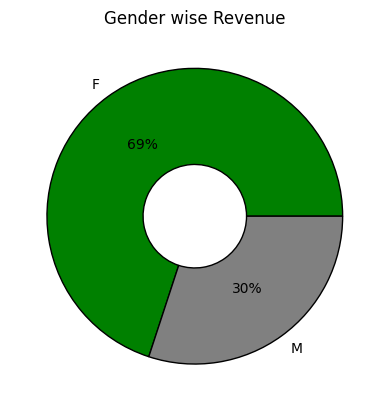

In [64]:
plt.pie(gs['Amount'], labels = gs['Gender'], autopct = '%d%%',colors = ['green','grey'], wedgeprops = {'width':0.65,'edgecolor':'black'})
plt.title('Gender wise Revenue')
plt.show()

#### TOP 5 STATE WISE REVENUE

In [31]:
sr = df.groupby('State')['Total Sales'].sum().reset_index()
sr.sort_values(by = 'Total Sales', ascending = False, inplace = True)
sr = sr.head(5)
sr.sort_values('Total Sales', ascending = True, inplace = True)

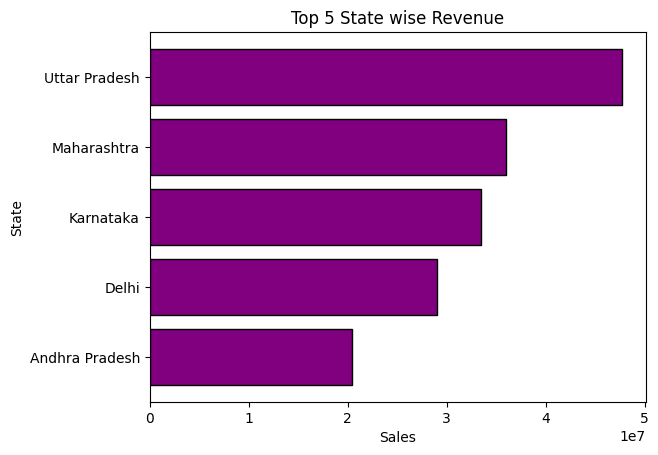

In [32]:
plt.barh(sr['State'], sr['Total Sales'], color = 'Purple', edgecolor = 'black')
plt.xlabel('Sales')
plt.ylabel('State')
plt.title('Top 5 State wise Revenue')
plt.show()

#### AGE-GROUP GENDER WISE REVENUE

In [33]:
## Adding a new column of Age Flag

condition = (df['Age'] > 60,
             df['Age'] > 40,
             df['Age'] > 30,
             df['Age'] > 18
            )

output = ['Senior Citizen','Senior','Adult','Teenage']


df['Age Flag'] = np.select(condition, output, 'Children')

In [34]:
ag = df.groupby(['Age Flag','Gender'])['Total Sales'].sum().reset_index()
ag

,Age Flag,Gender,Total Sales
0,Adult,F,58870093.97
1,Adult,M,21375797.00
2,Children,F,6839273.00
3,Children,M,4225801.00
4,Senior,F,49590377.00
5,Senior,M,21289035.00
6,Senior Citizen,F,5272542.00
7,Senior Citizen,M,3910121.00
8,Teenage,F,64734610.36
9,Teenage,M,27551159.00


In [35]:
f = ag[ag['Gender'] == 'F']
m = ag[ag['Gender'] == 'M']
print(f)
print(m)

         Age Flag Gender  Total Sales
0           Adult      F  58870093.97
2        Children      F   6839273.00
4          Senior      F  49590377.00
6  Senior Citizen      F   5272542.00
8         Teenage      F  64734610.36
         Age Flag Gender  Total Sales
1           Adult      M   21375797.0
3        Children      M    4225801.0
5          Senior      M   21289035.0
7  Senior Citizen      M    3910121.0
9         Teenage      M   27551159.0


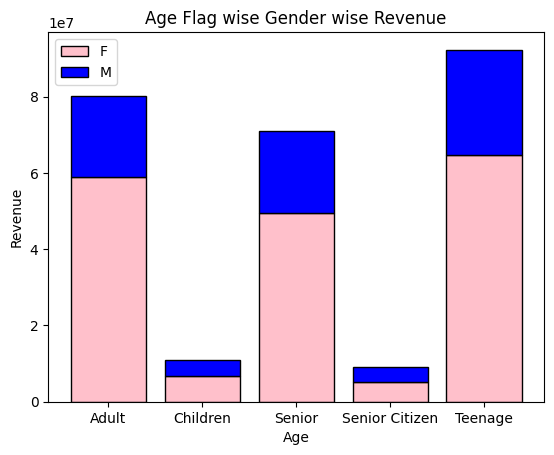

In [36]:
plt.bar(f['Age Flag'], f['Total Sales'], color = 'pink',edgecolor = 'black', label = 'F')
plt.bar(m['Age Flag'], m['Total Sales'], color = 'blue', edgecolor = 'black', bottom = f['Total Sales'], label = 'M')
plt.legend()
plt.xlabel('Age')
plt.ylabel('Revenue')
plt.title('Age Flag wise Gender wise Revenue')
plt.show()

#### TOP 5 CATEGORY WISE REVENUE

In [37]:
cg = df.groupby('Product_Category')['Total Sales'].sum().reset_index()
cg.sort_values('Total Sales', ascending = False, inplace = True)
cg = cg.head(5)
cg.sort_values('Total Sales', ascending = True, inplace = True)

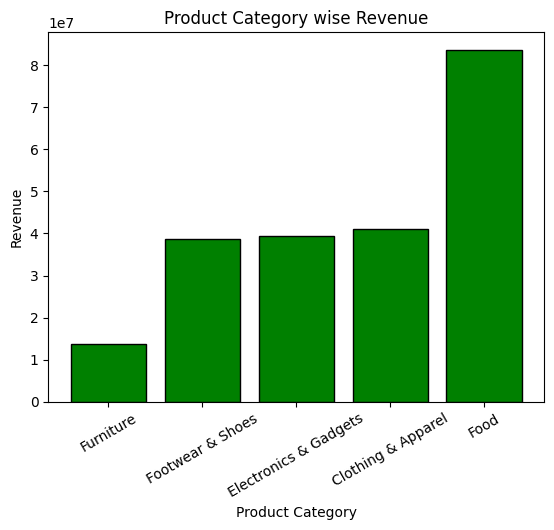

In [41]:
plt.bar(cg['Product_Category'],cg['Total Sales'], color = 'green', edgecolor = 'black')
plt.xticks(rotation = 30)
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.title('Product Category wise Revenue')
plt.show()

#### MARITAL_STATUS WISE REVENUE

In [43]:
df['Marital_Status'] = np.where(df['Marital_Status'] == 0,"Unmarried","Married")

In [46]:
mg = df.groupby('Marital_Status')['Total Sales'].sum().reset_index()

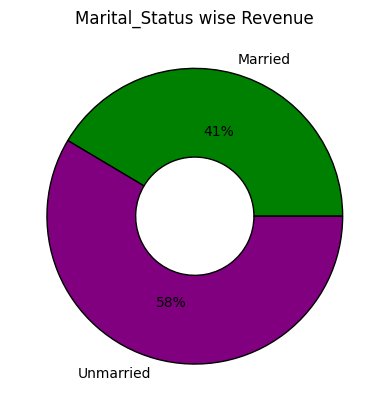

In [58]:
plt.pie(mg['Total Sales'], labels = mg['Marital_Status'], colors = ['green','purple'], 
        autopct = '%d%%',
        wedgeprops = {'width':0.60, 'edgecolor':'black'})
plt.title('Marital_Status wise Revenue')
plt.show()